#  Problem 1

| Task | Description |
|------|-------------|
| Task 1 | Dataset Preparation — corpus collection, preprocessing, statistics, word cloud |
| Task 2 | Model Training — 27 CBOW + 27 Skip-gram configurations |
| Task 3 | Semantic Analysis — nearest neighbors + analogy experiments |
| Task 4 | Visualization — PCA & t-SNE cluster plots |




---
##  Install & Import Libraries

In [18]:
# Install required libraries (gensim usually pre-installed in Colab)
!pip install gensim wordcloud --quiet

import re
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from itertools import product

from gensim.models import Word2Vec
from wordcloud import WordCloud
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print(' All libraries imported successfully.')

 All libraries imported successfully.


---
##  TASK 1 — Dataset Preparation
### 1.1 Raw Text Corpus (Collected from IIT Jodhpur Website)

**Sources used:**
1. CSE Department — Home, Vision/Mission
2. CSE Department — Doctoral Programs
3. CSE Department — Undergraduate Programs
4. Office of Academics — Collaborations (MoUs)
5. Academic Programs Overview
6. School of Liberal Arts — PhD Scholars
7. CSE Department — Research Areas & Labs
8. Electrical Engineering Department
9. PhD Admissions & Regulations
10. Placements & Industry Connect
11. Civil & Infrastructure Engineering
12. Mathematics & Physics Departments

In [19]:
# ─────────────────────────────────────────────────────────────────────
# RAW DOCUMENTS — Text scraped from IIT Jodhpur official pages
# Non-English text (Hindi etc.) is excluded at preprocessing stage
# ─────────────────────────────────────────────────────────────────────

raw_documents = {

"doc_01_cse_overview": """
Computer Science and Engineering today plays a major role in transforming every aspect of human life
in addressing social challenges and catalyzing the ongoing wave of the industrial revolution.
The department of computer science and engineering is driven by its commitment to excel in next
generation technology development and research. Our mission is to strengthen industry-academia
collaborations and prepare our students to contribute to multi-disciplinary projects and research
and development for solving problems of national interest.
Vision: To be among the top 10 departments in terms of research contributions, practical impact,
and applications of Computer Science and Engineering in the country in the next 3 years, and
internationally well known in some focused areas in the next 5 years.
Mission: Achieve excellence in research in fundamental as well as applied areas of CSE and allied
subject for innovative discoveries; develop an academic ecosystem by collaborating; and develop and
support the notion of computing for all across disciplines at the institute.
Achieving excellence in research in fundamental as well as applied areas of CSE and allied subjects
for innovative discoveries. Develop an academic ecosystem by collaborating within the institute as
well by means of international national and regional institutes. The collaborations may be fostered
by research visits collaborative projects joint thesis internship guidance research mentoring.
Embracing shared dialogue across disciplines and encouraging experiential learning to redefine the
contours of traditional Computer Science teaching and learning. Be one of the leading departments
in the country for hybrid CSE education. Define and solve real-world problems in collaboration with
industry and develop industry-connect by means of research grants consultancies and collaborative
projects. Develop Start-up ecosystem in emerging areas of computing in collaboration with other
departments at IIT Jodhpur. Provide thought leadership in public policy and ethics of emerging
computing technologies towards building an equitable and ethical society.
News: Dr. Debasis Das received DST-NSF Project Award 2025. Dr. Debasis Das received NSTC Research
Award-2025. Patent submitted on MFA-U-Net for Medical Image Segmentation funded by TiH iHub Drishti.
Research highlights: PatientVLM meets DocVLM for Efficient Diagnosis AAAI 2026. Temporal
Object-Aware Vision Transformer for Few-Shot Video Object Detection AAAI 2026. DBCoreset Algorithm
for Chest X-ray Diagnosis IEEE ISBI 2026.
Announcements: PhD Admission Result AY 2025-26 SEMESTER II. List of Shortlisted Candidates for
PhD AY 2025-26. Rolling Advertisement for admission to PhD Program. Rolling Advertisement for
faculty positions at IIT Jodhpur.
""",

"doc_02_doctoral_programs": """
IIT Jodhpur Doctoral Programs in Computer Science and Engineering.
MTech-PhD Dual Degree CSE and MTech-PhD Dual Degree AI programs have been offered since July 2019.
These programs have been designed particularly for students with an inclination for research.
Students who have completed their BTech are eligible to join this program. Students complete their
MTech course work and then start their research and earn both MTech and PhD degrees at the end.
Students are awarded a fellowship equivalent to that of a JRF from the date of their joining.
Programs facilitate students to decide upon their area of research by the end of the first semester.
After a phase of rigorous coursework in the first two years they start working towards the academic
requirements of a PhD that includes a comprehensive exam state-of-the-art seminar publications in
top conferences and journals and a thesis. Students can also work on industry projects and
collaborate with faculty from other academic and research bodies. This program offers PhD level
scholarship from the first year itself.
PhD CSE Program: The PhD program at the Department of Computer Science and Engineering at IIT
Jodhpur is postgraduate-research-oriented. A PhD student works in an area of interest under the
supervision of a faculty member and also has the flexibility to have an industry expert as
co-supervisor. The student has to complete the PhD qualifier requirements which involve a minimum
number of credits by taking courses a comprehensive exam state-of-the-art seminar and research
proposal defense. The doctoral program salient feature is the independent research work taken by
scholars leading to a thesis at the end of the program. The average duration of a PhD program is
between four to five years.
The CSE department invites students with a research bent of mind to apply for admission to the PhD
program. The PhD applicant must have high aspiration and willingness to work on socially relevant
cutting-edge problems. Strong foundations in core Computer Science subjects are expected. The
department offers admission to the PhD program in Full-Time and Part-Time categories.
PhD Tracks: MoE Funded PhD. PhD Funded by Exciting Projects. Joint PhD with SUNY Buffalo.
Broad Research Areas: AI and Machine Learning. Computer Vision Augmented Reality Virtual Reality.
Systems and Software. Theoretical Computer Science.
Specific research interests: Health Informatics Social Network Analysis Cryptography Computational
Social Choice Theory Parameterized Randomized Algorithms Graph Algorithms Natural Language
Understanding Quantum Computation IoT Blockchain Network Security.
Compute Facilities: Industry focused research-driven courses. Modern high-end GPU clusters
including NVIDIA DGX A100. State-of-the-Art testbeds in VANET. Samsung sponsored AR-VR lab.
Research Opportunities: Industry-sponsored projects from Meta IBM TCS DRDO Microsoft Accenture.
Government collaborations with DRDO AIIMS PGI Law Enforcement. Academic collaborations with
IIT Bombay IIT Kharagpur IIIT Guwahati IIT Delhi IISc Bangalore SUNY Buffalo Hong Kong
Polytechnic University Missouri University Ben-Gurion University of the Negev.
Publications at top conferences NeurIPS CVPR ACL AAAI and premier journals.
Alumni at Charles University American Express Czech Technical University IIT Roorkee.
Joint PhD SUNY Buffalo: Dissertation jointly directed by faculty from both institutions.
Students awarded two separate PhD degrees one from each institution.
GATE qualification mandatory for PhD admissions from India.
""",

"doc_03_undergraduate_programs": """
IIT Jodhpur Undergraduate Programs in Computer Science and Engineering.
BTech Computer Science and Engineering CSE program aims to equip students with skills to undertake
careers that involve identifying and engineering solutions for real-world problems through
innovating upon their core competence in computer science. The curriculum gives due importance to
the foundational aspects of computer science as well as aspires to inculcate in students the
foresight and expertise to address transdisciplinary technological questions. Students can choose
from a number of elective courses across Theory and Algorithms Hardware Systems Network and
Security Artificial Intelligence Machine Learning Speech Vision Language and Social Computing.
Specialization tracks include Visual Computing Socio-Digital Reality Advanced Algorithms Social
and Sustainable Computing Intelligent Communication and Networking VLSI Systems.
Program aspires to produce a motivated workforce who would embark upon careers in research and
industry involving innovation knowledge creation engineering and entrepreneurship. All graduates
are currently placed in companies of repute or pursuing higher education in top-tier universities.
BTech Artificial Intelligence and Data Science program starting 2020 envisions equipping students
with the ability to assess societal health safety legal and cultural issues and identify their
consequent responsibilities as engineers of effective solutions.
The curriculum is interdisciplinary straddling computer science mathematics artificial intelligence
machine learning data science and their applications across domains. Courses include Artificial
Intelligence Deep Learning Digital Image Processing Computer Vision Video Processing Biometrics
Dependable AI Resource-constrained AI Big Data Data Engineering Data Visualization Stream
Analytics Social Network Analysis Human-Machine Interaction Augmented and Virtual Reality Speech
and Natural Language Understanding Computational Neuroscience.
The program provides transdisciplinary specialization in visual computing socio-digital reality
intelligent communications networking language technologies robotics and AIoT. Students can
venture into a Management specialization leading to MBA BTech MBA dual degree program.
""",

"doc_04_academic_collaboration": """
IIT Jodhpur Academic Collaborations and Memoranda of Understanding MoUs.
The Institute has signed MoUs with six international universities two international agencies
three national institutes and universities and one national agency.
University of Western Ontario Canada: Explore possibilities for cooperation in education training
and research and to encourage direct contact and mutual cooperation between faculty members
departments and research centers.
Universitat Rovira I Virgili Spain: Develop mutually beneficial academic program and courses;
coordination of academic staff travel for teaching research and training; cooperation of student
mobility program for study research and joint academic activities such as research publications
conferences and symposia; exchange of documentation and research materials.
University of Waterloo Canada: Collaborate to foster international experience and advancement of
knowledge on the basis of reciprocity mutual benefit interaction and exchange of students in
graduate programs.
University of Manitoba Canada: Develop mutually beneficial programs for student internships and
graduate study in order to provide students opportunities for advancement of knowledge.
University of California Merced USA: Develop mutually beneficial relationships for promoting
academic exchange scholarly cooperation and collaborations including exchange of faculty members
scientists and students access to library resources pursuit of joint meetings symposia conferences
and access to laboratories.
Institute of Science and Technology Nara Japan: Promote academic exchanges including implementation
of collaborative research joint symposia lectures exchange of scholars researchers administrative
staff and graduate students.
International Agencies: Cooperate in areas of solar energy research Concentrated Solar Power CSP
Concentrated Photovoltaic CPV water production by solar energy renewable energy storage smart
management integration of solar energies and energy efficiency in buildings.
National Collaborations: All India Institute of Medical Sciences Jodhpur AIIMS. National Law
University Jodhpur. Sardar Patel University of Police Security and Criminal Justice Jodhpur.
Collaborate in various academic activities in the spheres of expertise.
""",

"doc_05_academic_programs_overview": """
IIT Jodhpur Academic Programs Overview.
The Institute offers Academic Programs including Bachelor of Technology BTech Master of Science MSc
Master of Technology MTech MTech-PhD Dual Degree Doctor of Philosophy PhD and MS by Research.
IIT Jodhpur is organized into departments: Bioscience and Bioengineering Chemical Engineering
Chemistry Civil and Infrastructure Engineering Computer Science and Engineering Electrical
Engineering Mathematics Mechanical Engineering Metallurgical and Materials Engineering Physics.
Schools include School of Management and Entrepreneurship and School of Liberal Arts.
BTech Programs admit students through JEE Advanced. BTech program spans 4 years. MSc programs
span 2 years for students who have completed undergraduate education in science. MTech programs
are of 2 years duration for students who have completed BTech or equivalent. PhD programs are
research-oriented and typically span 4 to 5 years.
Academic regulations govern the conduct of all academic programs at IIT Jodhpur. Students must
fulfill credit requirements for their respective programs. Examinations are conducted at regular
intervals. Attendance is mandatory for all courses. CGPA requirements must be met for continuation.
The Office of Academics Affairs manages academic programs calendar and related activities.
Academic calendar defines the schedule for the academic year including start and end dates of
semesters examination schedules and holidays.
Graduation requirements include satisfactory completion of required credits project work and
seminar presentations for research programs. The institute conducts convocation ceremonies to
award degrees to graduating students.
Interdisciplinary programs and dual degree options are available. Students can pursue
specializations in various areas. Elective courses enable students to expand knowledge.
""",

"doc_06_liberal_arts_phd": """
IIT Jodhpur School of Liberal Arts PhD Scholars and Research Areas.
Major research groups in the School of Liberal Arts follow disciplinary and interdisciplinary
tracks: Literature Linguistics and Cultural Studies Philosophy Psychology Sociology Economics.
PhD Scholar Research Interests: Philosophy of Mind and Cognition. Ideas of the Self Embodied
Cognition Philosophy of Mind. Phenomenology and Ethics. Mind-Wandering Mindfulness Virtue Ethics.
Clinical Psychology Neuropsychology Therapeutic interventions Childhood Trauma Developmental
Psychology. Dalit Studies Social Anthropology of Caste Himalayan Studies. Sociology of sanitation
Social exclusion and inclusion Caste poverty inequality and fairness Public Policy.
Childhood Education Heritage Everyday Life. Cinema and Mobilization Cine-politics Populism
Popular Cinema. Film Studies Transnational Cinema Identities and Feminism New Media Social
Politics. Literary Cultural and Media Studies Digital Humanities. Gender studies Intersectionality
Fiction Indian English Literature Translation studies. Ecological Posthumanism Science Fiction
Climate Fiction Anthropocene Literature Eco-horror Dystopian Novels. Theatre Historiography
Performance Archive Theatre and Public. Gerontology Economics of Ageing Health Economics
Large Scale Sample Survey Sampling Technique Econometrics Public Policy. Maternal Health Quality
of Care Equity and Social Justice Global Healthcare Development Studies Public Policy.
The School of Liberal Arts offers Undergraduate Courses Postgraduate Program in Computational
Social Science MSc and Doctoral Program. The school has laboratories including Digital Language
Laboratory and Psychology Lab. Students pursue interdisciplinary research combining humanities
and social sciences with technology and computing. The MSc program in Computational Social
Science combines social science methods with data analysis and computation.
""",

"doc_07_research_areas_cse": """
IIT Jodhpur CSE Department Research Areas and Laboratories.
Artificial Intelligence and Machine Learning: Research covers deep learning neural networks
natural language processing computer vision reinforcement learning federated learning and AI
applications in healthcare biometrics and social networks. Faculty work on health informatics
medical image analysis face recognition document understanding and AI ethics. Students have
access to NVIDIA DGX A100 GPU clusters for deep learning research. Collaboration with iHub
Drishti for computer vision research.
Vision and AR-VR: Research in computer vision including image and video processing object
detection recognition video understanding few-shot learning and multimodal learning. Research
in augmented reality and virtual reality including immersive environments spatial computing and
human-computer interaction. Samsung sponsored AR-VR lab provides state-of-the-art equipment.
Systems and Software: Research in operating systems computer architecture compilers programming
languages distributed systems cloud computing edge computing and software engineering. Work on
network security blockchain Internet of Things IoT vehicular ad hoc networks VANET cybersecurity.
Theoretical Computer Science: Research in algorithms complexity theory combinatorics graph theory
cryptography quantum computing parameterized algorithms randomized algorithms computational
social choice theory.
Industry Sponsors: Meta IBM TCS DRDO Microsoft Accenture provide research grants and collaborate
on projects. Government collaborations with DRDO AIIMS PGI and law enforcement agencies.
Academic collaborations with IIT Bombay IIT Kharagpur IISc Bangalore SUNY Buffalo Hong Kong
Polytechnic University Missouri University of Science and Technology IIT Hyderabad.
PhD students publish at top conferences including AAAI NeurIPS CVPR ACL IEEE conferences and
premier journals. Students receive travel support to attend conferences. Reading groups and
weekly seminars foster research culture.
""",

"doc_08_electrical_engineering": """
IIT Jodhpur Department of Electrical Engineering.
The Department of Electrical Engineering at IIT Jodhpur offers undergraduate postgraduate and
doctoral programs. The BTech program in Electrical Engineering equips students with fundamental
knowledge and skills in electrical systems electronics signal processing communications and
control systems. The MTech program offers advanced training in specialized areas. The PhD program
focuses on research in frontier areas of electrical engineering.
Research areas: Signal Processing and Communications including digital signal processing wireless
communications satellite communications channel coding OFDM systems MIMO systems antenna design.
Power Systems and Energy including power electronics renewable energy systems smart grids energy
storage and electric vehicles. VLSI and Embedded Systems including digital circuit design VLSI
design embedded systems reconfigurable computing and mixed signal design. Control and Automation
including control theory robotics autonomous systems industrial automation and mechatronics.
The department has well-equipped laboratories for student research and experimentation. Faculty
members collaborate with industry and government agencies on funded research projects. Students
receive training in both theoretical foundations and practical applications.
Students in the department have achieved distinction in national and international competitions
and publications. The department maintains strong connections with industry through internship
programs and placement activities.
""",

"doc_09_admissions_phd": """
IIT Jodhpur PhD Admissions and Regulations.
IIT Jodhpur invites applications for admission to PhD programs across all departments including
Computer Science and Engineering Electrical Engineering Mechanical Engineering Civil Engineering
Chemical Engineering Physics Chemistry Mathematics Bioscience and Bioengineering and
Metallurgical and Materials Engineering. The School of Liberal Arts also offers doctoral program.
Eligibility for PhD Admission: Candidates with a Masters degree in a relevant discipline are
eligible to apply. Candidates with BTech or equivalent degree with exceptional academic record
may be considered for direct PhD admission. GATE qualification is mandatory for most PhD
admissions. CSIR-UGC NET JRF qualification is also accepted for science PhD programs.
PhD Scholarship and Fellowship: Students admitted to full-time PhD program receive monthly
scholarship as per Ministry of Education guidelines. JRF fellowship is given for first two years.
SRF fellowship is given from third year onwards subject to satisfactory research progress.
Additional research contingency grants are available for experimental and travel expenses.
PhD Program Structure: The PhD program consists of coursework and research phases. In first year
students complete required coursework to strengthen foundational knowledge. Students must pass
comprehensive examination to demonstrate mastery of their research area. Students present
state-of-the-art seminar surveying the literature in their area. Students present research
proposal evaluated by the doctoral committee. Subsequently students engage in full-time research
leading to the doctoral thesis. Students must publish research findings in peer-reviewed venues
before thesis submission. Thesis is evaluated by external examiners followed by oral defense
called viva voce.
IIT Jodhpur fosters a vibrant research culture with regular seminars workshops and conferences.
The institute invites eminent scientists from leading institutions worldwide for guest lectures
and collaborative research. Interdisciplinary research is encouraged through joint projects.
""",

"doc_10_placements_industry": """
IIT Jodhpur Placements and Industry Connections.
IIT Jodhpur students have been consistently placed in top companies across technology consulting
finance and research institutions. Campus recruitment drives allow leading companies to select
students through a structured interview process.
Major recruiters include Google Microsoft Amazon Meta Apple Adobe Qualcomm NVIDIA Texas Instruments
and various Indian IT companies. Students from CSE department received offers from top technology
firms both in India and abroad. Students from other departments find placements in core engineering
companies consulting firms and management companies.
The placement cell at IIT Jodhpur coordinates recruitment activities prepares students for
interviews and maintains relationships with industry partners. Mock interviews resume workshops
and aptitude training sessions are conducted regularly to prepare students for placement process.
Higher Studies: A significant proportion of students from IIT Jodhpur pursue higher studies after
graduation. Many students are admitted to top graduate programs in universities such as MIT
Stanford CMU University of California Berkeley University of Toronto IISc Bangalore and various
IITs. Students pursue Masters and PhD programs in their respective disciplines.
Entrepreneurship: IIT Jodhpur encourages entrepreneurship through Center for Continuing Corporate
Development. The institute startup ecosystem supports student ventures in emerging technology
areas. Several alumni have founded successful startups in artificial intelligence fintech edtech
and healthcare technology.
Industry Connect: The department organizes annual Industry Connect events where companies interact
with students and faculty to explore collaboration opportunities. Research partnerships with
industry sponsors have led to funded projects and internship opportunities for students.
Industry experts are regularly invited as guest lecturers and adjunct faculty.
""",

"doc_11_civil_infrastructure": """
IIT Jodhpur Department of Civil and Infrastructure Engineering.
The Civil and Infrastructure Engineering department offers programs at undergraduate postgraduate
and doctoral levels. The department conducts research in Structural Engineering Environmental
Engineering Geotechnical Engineering Geological Engineering Transportation Engineering Water
Resource Engineering and Computational Laboratory.
Research projects cover sustainable infrastructure earthquake engineering water management traffic
systems and environmental remediation. Faculty members have received research grants from
government agencies and industry partners.
Academic programs include BTech in Civil and Infrastructure Engineering MTech programs in
specialized areas and the doctoral PhD program. Students have access to well-equipped laboratories
for experimental research and computational facilities for simulation and modeling studies.
The department maintains MoUs with national and international institutions for academic exchange
and collaborative research. Students participate in national and international competitions and
present their research at premier conferences and journals.
""",

"doc_12_mathematics_physics": """
IIT Jodhpur Departments of Mathematics and Physics.
Mathematics Department: Research in pure and applied mathematics including Analysis Algebra
Topology Differential Equations Numerical Analysis Computational Mathematics Mathematical Physics
Optimization Statistics and Probability Theory. The department offers MSc and PhD programs.
Faculty collaborate with engineering and science departments on interdisciplinary research.
Physics Department: Research in experimental and theoretical physics including Condensed Matter
Physics Optical Physics Biophysics Astrophysics Quantum Physics High Energy Physics and Material
Science. The department offers MSc and PhD programs. Faculty members use national and international
research facilities for their experimental work.
Both departments contribute to undergraduate science and engineering education at IIT Jodhpur.
Faculty from mathematics and physics departments teach foundational courses to all BTech students.
Research students receive training in advanced mathematical physical concepts and experimental or
computational techniques.
Interdisciplinary Research: Mathematics and physics departments collaborate extensively with
engineering departments and Center for Advanced Scientific Equipment to pursue interdisciplinary
research. Joint projects in quantum computing data science materials science and computational
biology bring together expertise from multiple departments.
"""
}

print(f' Loaded {len(raw_documents)} raw documents from IIT Jodhpur sources.')

 Loaded 12 raw documents from IIT Jodhpur sources.


### 1.2 Preprocessing Pipeline

In [20]:
# ─────────────────────────────────────────────────────────────────────
# STOPWORD LIST (95 common English function words)
# ─────────────────────────────────────────────────────────────────────
STOPWORDS = set([
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'by','from','as','is','was','are','were','be','been','being','have',
    'has','had','do','does','did','will','would','could','should','may',
    'might','shall','can','need','this','that','these','those','it','its',
    'he','she','they','we','i','me','him','her','them','us','my','your',
    'his','our','their','which','who','whom','whose','when','where','how',
    'what','why','not','no','nor','so','yet','both','either','each','all',
    'any','few','more','most','other','such','only','own','same','than',
    'too','very','just','about','into','through','during','before','after',
    'above','below','between','out','off','over','under','again','further',
    'then','also','up','down','there','here','if','because','while',
    'although','though','since','unless','until','whether','among','across',
    'along','around','behind','beyond','within','without',
])

def preprocess_text(text):
    """Full preprocessing pipeline for one document."""
    text = re.sub(r'http\S+|www\S+', '', text)      # Step 1: Remove URLs
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)      # Step 2: Remove non-ASCII (Hindi etc.)
    text = text.lower()                               # Step 3: Lowercase
    text = re.sub(r'[^\w\s]', ' ', text)             # Step 4: Remove punctuation
    text = re.sub(r'\d+', '', text)                  # Step 5: Remove digits
    text = re.sub(r'\s+', ' ', text).strip()         # Step 6: Normalize whitespace
    return text

def tokenize_and_filter(text):
    """Tokenize, remove stopwords, remove short tokens."""
    tokens = text.split()                             # Step 7: Tokenize
    tokens = [t for t in tokens
               if t not in STOPWORDS and len(t) > 2] # Step 8: Filter
    return tokens

# ─────────────────────────────────────────────────────────────────────
# PROCESS ALL DOCUMENTS
# ─────────────────────────────────────────────────────────────────────
processed_docs = {}
all_tokens     = []
corpus_lines   = []

for doc_name, raw_text in raw_documents.items():
    cleaned = preprocess_text(raw_text)
    tokens  = tokenize_and_filter(cleaned)
    processed_docs[doc_name] = {'cleaned': cleaned, 'tokens': tokens}
    all_tokens.extend(tokens)
    corpus_lines.append(cleaned)

# Build vocabulary frequency
vocab = Counter(all_tokens)

# Build sentence chunks for Word2Vec (20-token windows)
sentences_for_w2v = []
for data in processed_docs.values():
    toks = data['tokens']
    for i in range(0, len(toks), 20):
        chunk = toks[i:i+20]
        if len(chunk) >= 5:
            sentences_for_w2v.append(chunk)

print(' Preprocessing complete.')

 Preprocessing complete.


### 1.3 Dataset Statistics

In [21]:
total_docs             = len(processed_docs)
total_tokens_raw       = sum(len(d['cleaned'].split()) for d in processed_docs.values())
total_tokens_filtered  = len(all_tokens)
vocab_size             = len(vocab)
num_sentences          = len(sentences_for_w2v)

print('=' * 55)
print('       DATASET STATISTICS — IIT Jodhpur Corpus')
print('=' * 55)
print(f'  Total Documents              : {total_docs}')
print(f'  Total Tokens (raw cleaned)   : {total_tokens_raw}')
print(f'  Total Tokens (no stopwords)  : {total_tokens_filtered}')
print(f'  Vocabulary Size              : {vocab_size}')
print(f'  Sentences/Chunks for W2V     : {num_sentences}')
print('=' * 55)
print('\n  Top 30 Most Frequent Words:')
print(f'  {"Word":<22} Freq')
print(f'  {"-"*30}')
for word, count in vocab.most_common(30):
    print(f'  {word:<22} {count}')

       DATASET STATISTICS — IIT Jodhpur Corpus
  Total Documents              : 12
  Total Tokens (raw cleaned)   : 3305
  Total Tokens (no stopwords)  : 2449
  Vocabulary Size              : 955
  Sentences/Chunks for W2V     : 125

  Top 30 Most Frequent Words:
  Word                   Freq
  ------------------------------
  research               77
  students               54
  phd                    44
  engineering            41
  science                32
  iit                    31
  program                29
  programs               29
  jodhpur                27
  computer               23
  academic               23
  department             20
  industry               18
  social                 16
  systems                16
  including              16
  university             15
  departments            14
  areas                  14
  computing              14
  faculty                14
  learning               13
  projects               12
  btech                  12
 

### 1.4 Word Cloud & Frequency Bar Chart

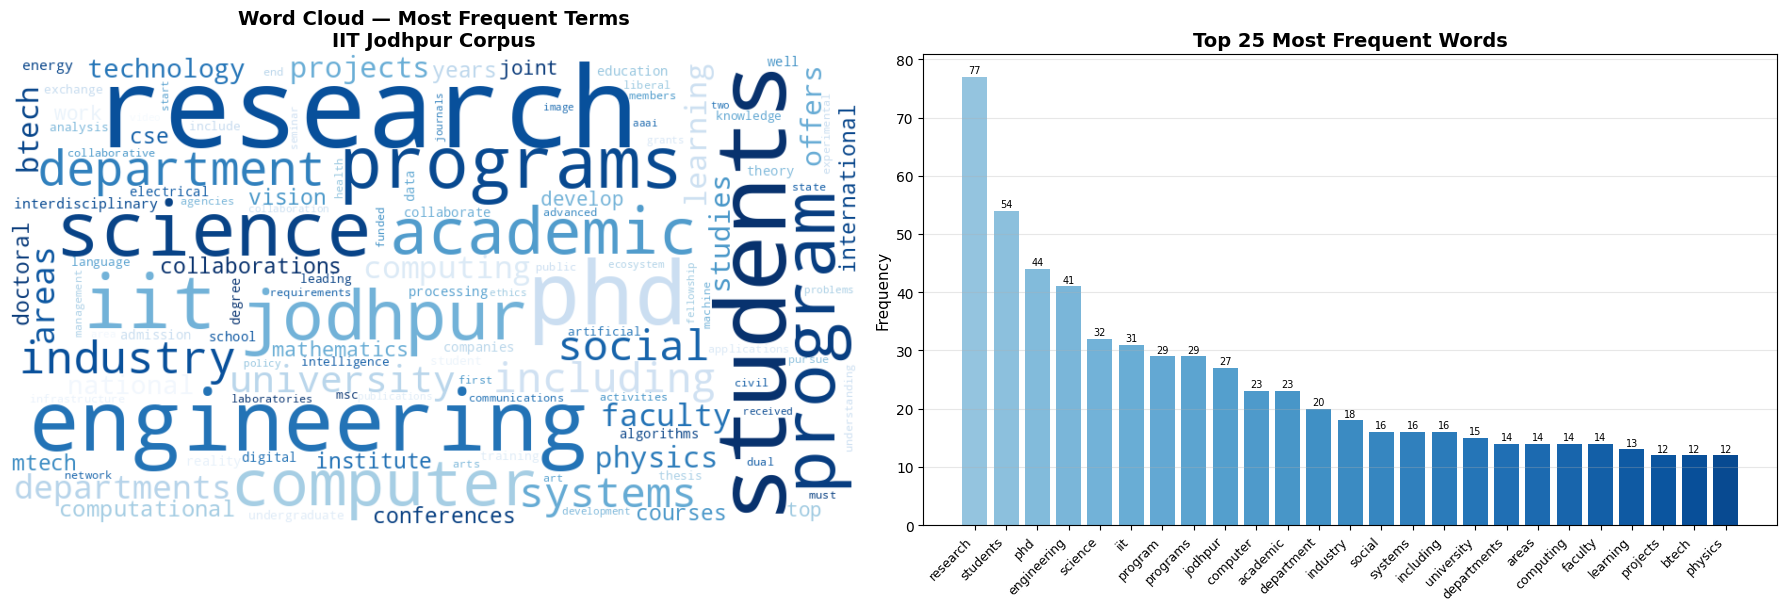

 Task 1 visualizations saved.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Word Cloud ──────────────────────────────────────────────────────
wc = WordCloud(
    width=900, height=500,
    background_color='white',
    colormap='Blues',
    max_words=120,
    min_font_size=10,
    max_font_size=120,
    prefer_horizontal=0.8
).generate_from_frequencies(dict(vocab.most_common(150)))

axes[0].imshow(wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud — Most Frequent Terms\nIIT Jodhpur Corpus',
                   fontsize=14, fontweight='bold')

# ── Frequency Bar Chart ─────────────────────────────────────────────
top25_words, top25_counts = zip(*vocab.most_common(25))
colors_bar = plt.cm.Blues(np.linspace(0.4, 0.9, 25))
bars = axes[1].bar(range(25), top25_counts, color=colors_bar)
axes[1].set_xticks(range(25))
axes[1].set_xticklabels(top25_words, rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Top 25 Most Frequent Words', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for bar, count in zip(bars, top25_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(count), ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('task1_wordcloud_and_frequency.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Task 1 visualizations saved.')

---
##  TASK 2 — Model Training
### 2.1 Train All 54 Word2Vec Configurations (27 CBOW + 27 Skip-gram)

In [23]:
# ─────────────────────────────────────────────────────────────────────
# HYPERPARAMETER GRID
# ─────────────────────────────────────────────────────────────────────
EMBEDDING_DIMS    = [50, 100, 200]
WINDOW_SIZES      = [3, 5, 7]
NEGATIVE_SAMPLES  = [5, 10, 15]

# Best config for Tasks 3 & 4
BEST_DIM, BEST_WIN, BEST_NEG = 100, 5, 5

training_results = []
best_cbow_model  = None
best_sg_model    = None

print('Training 54 Word2Vec models...')
print(f'{"Model":<45} {"Vocab":>6}  {"Time(s)":>8}')
print('-' * 65)

for sg_flag, arch_name in [(0, 'CBOW'), (1, 'SkipGram')]:
    for dim in EMBEDDING_DIMS:
        for win in WINDOW_SIZES:
            for neg in NEGATIVE_SAMPLES:

                t0 = time.time()
                model = Word2Vec(
                    sentences    = sentences_for_w2v,
                    vector_size  = dim,
                    window       = win,
                    negative     = neg,
                    sg           = sg_flag,   # 0=CBOW, 1=Skip-gram
                    hs           = 0,         # use negative sampling
                    min_count    = 1,
                    workers      = 4,
                    epochs       = 50,
                    seed         = 42
                )
                elapsed   = round(time.time() - t0, 3)
                vocab_sz  = len(model.wv)
                key       = f'{arch_name}_dim{dim}_win{win}_neg{neg}'

                print(f'  {key:<43} {vocab_sz:>6}  {elapsed:>8}')

                training_results.append({
                    'Architecture'   : arch_name,
                    'Embedding Dim'  : dim,
                    'Window Size'    : win,
                    'Negative Samples': neg,
                    'Vocab Size'     : vocab_sz,
                    'Train Time (s)' : elapsed
                })

                # Save best models
                if dim == BEST_DIM and win == BEST_WIN and neg == BEST_NEG:
                    if arch_name == 'CBOW':
                        best_cbow_model = model
                        model.save('best_cbow.model')
                    else:
                        best_sg_model = model
                        model.save('best_skipgram.model')

print(f'\n Training complete. {len(training_results)} models trained.')
print(f'   Best CBOW     saved → best_cbow.model')
print(f'   Best Skip-gram saved → best_skipgram.model')

Training 54 Word2Vec models...
Model                                          Vocab   Time(s)
-----------------------------------------------------------------
  CBOW_dim50_win3_neg5                           955     0.378
  CBOW_dim50_win3_neg10                          955     0.897
  CBOW_dim50_win3_neg15                          955     0.646
  CBOW_dim50_win5_neg5                           955      0.44
  CBOW_dim50_win5_neg10                          955     0.757
  CBOW_dim50_win5_neg15                          955     1.327
  CBOW_dim50_win7_neg5                           955     0.829
  CBOW_dim50_win7_neg10                          955     1.181
  CBOW_dim50_win7_neg15                          955     1.753
  CBOW_dim100_win3_neg5                          955     1.478
  CBOW_dim100_win3_neg10                         955     1.472
  CBOW_dim100_win3_neg15                         955     1.244
  CBOW_dim100_win5_neg5                          955     0.676
  CBOW_dim100_win5_ne

### 2.2 Training Results Summary Table

In [24]:
# Show results for neg=5 configurations (representative subset)
print(f'{"Architecture":<12} {"Dim":>5} {"Win":>5} {"Neg":>5} {"Vocab":>7} {"Time(s)":>9}')
print('-' * 50)
for r in training_results:
    if r['Negative Samples'] == 5:
        print(f"{r['Architecture']:<12} {r['Embedding Dim']:>5} "
              f"{r['Window Size']:>5} {r['Negative Samples']:>5} "
              f"{r['Vocab Size']:>7} {r['Train Time (s)']:>9}")

Architecture   Dim   Win   Neg   Vocab   Time(s)
--------------------------------------------------
CBOW            50     3     5     955     0.378
CBOW            50     5     5     955      0.44
CBOW            50     7     5     955     0.829
CBOW           100     3     5     955     1.478
CBOW           100     5     5     955     0.676
CBOW           100     7     5     955     0.634
CBOW           200     3     5     955     0.954
CBOW           200     5     5     955     1.454
CBOW           200     7     5     955      1.26
SkipGram        50     3     5     955     0.657
SkipGram        50     5     5     955     0.936
SkipGram        50     7     5     955     1.042
SkipGram       100     3     5     955     0.592
SkipGram       100     5     5     955     0.761
SkipGram       100     7     5     955     0.911
SkipGram       200     3     5     955     1.054
SkipGram       200     5     5     955     1.142
SkipGram       200     7     5     955     1.079


### 2.3 Training Time Heatmap

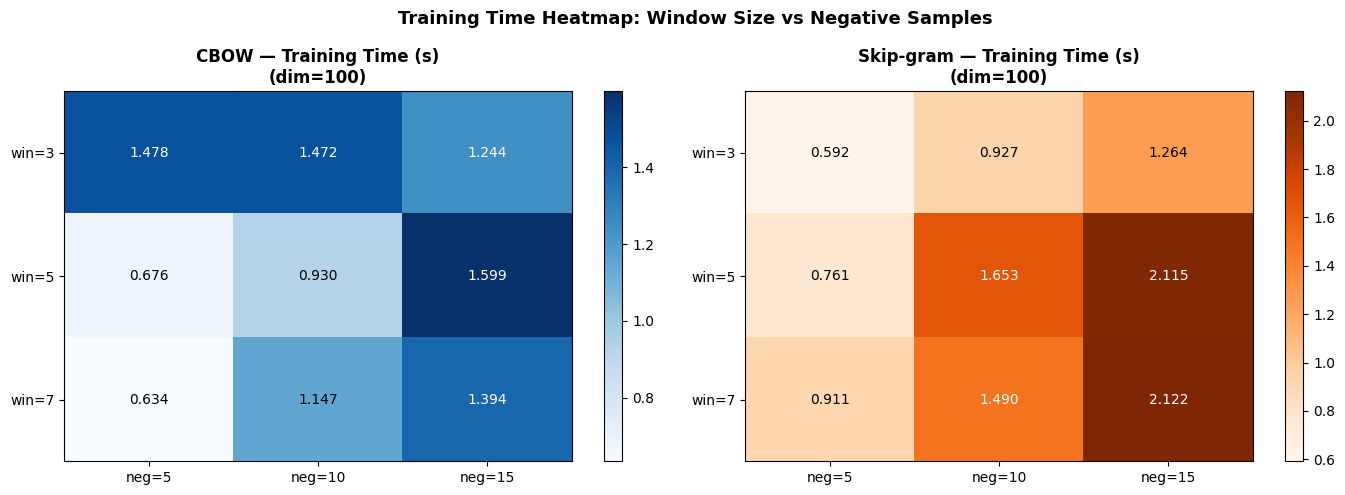

 Task 2 heatmap saved.


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, arch_name, cmap in zip(axes,
        ['CBOW', 'SkipGram'], ['Blues', 'Oranges']):

    # Build heatmap matrix: rows=window sizes, cols=neg samples, fixed dim=100
    data = np.zeros((len(WINDOW_SIZES), len(NEGATIVE_SAMPLES)))
    for i, win in enumerate(WINDOW_SIZES):
        for j, neg in enumerate(NEGATIVE_SAMPLES):
            r = next(x for x in training_results
                     if x['Architecture'] == arch_name
                     and x['Embedding Dim'] == 100
                     and x['Window Size'] == win
                     and x['Negative Samples'] == neg)
            data[i, j] = r['Train Time (s)']

    im = ax.imshow(data, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(NEGATIVE_SAMPLES)))
    ax.set_yticks(range(len(WINDOW_SIZES)))
    ax.set_xticklabels([f'neg={n}' for n in NEGATIVE_SAMPLES])
    ax.set_yticklabels([f'win={w}' for w in WINDOW_SIZES])
    arch_label = 'CBOW' if arch_name == 'CBOW' else 'Skip-gram'
    ax.set_title(f'{arch_label} — Training Time (s)\n(dim=100)', fontweight='bold')
    for i in range(len(WINDOW_SIZES)):
        for j in range(len(NEGATIVE_SAMPLES)):
            ax.text(j, i, f'{data[i,j]:.3f}', ha='center', va='center', fontsize=10,
                    color='white' if data[i,j] > data.mean() else 'black')
    plt.colorbar(im, ax=ax)

plt.suptitle('Training Time Heatmap: Window Size vs Negative Samples',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('task2_training_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Task 2 heatmap saved.')

---
##  TASK 3 — Semantic Analysis
### 3.1 Top-5 Nearest Neighbors (Cosine Similarity)
Using the **best models** (dim=100, win=5, neg=5)

In [26]:
TARGET_WORDS = ['research', 'student', 'phd', 'exam', 'engineering']

nn_results = {}

print('TOP-5 NEAREST NEIGHBORS (Best Models: dim=100, win=5, neg=5)')
print('=' * 70)

for word in TARGET_WORDS:
    nn_results[word] = {'cbow': [], 'skipgram': []}
    print(f"\n  Word: '{word}'")
    print(f"  {'Rank':<6} {'CBOW Neighbor':<25} {'CBOW Sim':>10}   "
          f"{'SG Neighbor':<25} {'SG Sim':>10}")
    print(f"  {'-'*75}")

    cbow_nbrs = best_cbow_model.wv.most_similar(word, topn=5) if word in best_cbow_model.wv else []
    sg_nbrs   = best_sg_model.wv.most_similar(word, topn=5)   if word in best_sg_model.wv   else []
    nn_results[word]['cbow']     = cbow_nbrs
    nn_results[word]['skipgram'] = sg_nbrs

    for rank in range(5):
        cw = cbow_nbrs[rank][0] if rank < len(cbow_nbrs) else '—'
        cs = f"{cbow_nbrs[rank][1]:.4f}" if rank < len(cbow_nbrs) else '—'
        sw = sg_nbrs[rank][0]   if rank < len(sg_nbrs)   else '—'
        ss = f"{sg_nbrs[rank][1]:.4f}" if rank < len(sg_nbrs) else '—'
        print(f"  {rank+1:<6} {cw:<25} {cs:>10}   {sw:<25} {ss:>10}")

print('\n Nearest neighbor analysis complete.')

TOP-5 NEAREST NEIGHBORS (Best Models: dim=100, win=5, neg=5)

  Word: 'research'
  Rank   CBOW Neighbor               CBOW Sim   SG Neighbor                   SG Sim
  ---------------------------------------------------------------------------
  1      students                      0.9997   encouraged                    0.8597
  2      industry                      0.9996   experimental                  0.8573
  3      studies                       0.9996   collaborate                   0.8502
  4      well                          0.9996   faculty                       0.8386
  5      requirements                  0.9996   experimentation               0.8338

  Word: 'student'
  Rank   CBOW Neighbor               CBOW Sim   SG Neighbor                   SG Sim
  ---------------------------------------------------------------------------
  1      students                      0.9996   bodies                        0.9311
  2      requirements                  0.9996   conduct         

### 3.2 Analogy Experiments
Format: `vec(B) − vec(A) + vec(C)` → finds word closest to the result vector

In [27]:
# Each analogy: (positive_words, negative_words, description)
analogies = [
    (['mtech', 'phd'],          ['btech'],      'UG:BTech :: PG:?  →  btech→mtech :: ?→phd'),
    (['research', 'phd'],       ['student'],    'student:courses :: research:?'),
    (['computer', 'engineering'],['science'],   'science:research :: engineering:?'),
    (['national', 'international'],['india'],   'india:national :: abroad:?'),
]

print('ANALOGY EXPERIMENTS')
print('=' * 70)

for pos, neg, description in analogies:
    print(f"\n  Analogy: {description}")
    print(f"  {'Rank':<6} {'CBOW Answer':<25} {'Score':>8}   {'SG Answer':<25} {'Score':>8}")
    print(f"  {'-'*75}")

    for model, name, key in [
            (best_cbow_model, 'CBOW', 'cbow'),
            (best_sg_model,   'SG',   'sg')]:
        missing = [w for w in pos + neg if w not in model.wv]
        if missing:
            results_an = [('N/A — word not in vocab', 0.0)] * 5
        else:
            results_an = model.wv.most_similar(positive=pos, negative=neg, topn=5)

        if key == 'cbow':
            cbow_an = results_an
        else:
            sg_an   = results_an

    for i in range(5):
        cw = cbow_an[i][0] if i < len(cbow_an) else '—'
        cs = f"{cbow_an[i][1]:.4f}" if i < len(cbow_an) else '—'
        sw = sg_an[i][0]   if i < len(sg_an)   else '—'
        ss = f"{sg_an[i][1]:.4f}" if i < len(sg_an) else '—'
        print(f"  {i+1:<6} {cw:<25} {cs:>8}   {sw:<25} {ss:>8}")

print('\n Analogy experiments complete.')

ANALOGY EXPERIMENTS

  Analogy: UG:BTech :: PG:?  →  btech→mtech :: ?→phd
  Rank   CBOW Answer                  Score   SG Answer                    Score
  ---------------------------------------------------------------------------
  1      degree                      0.9984   admission                   0.8826
  2      program                     0.9983   rolling                     0.8697
  3      admission                   0.9982   advertisement               0.8678
  4      philosophy                  0.9982   candidates                  0.8611
  5      programs                    0.9981   degree                      0.8543

  Analogy: student:courses :: research:?
  Rank   CBOW Answer                  Score   SG Answer                    Score
  ---------------------------------------------------------------------------
  1      program                     0.9989   interdisciplinary           0.7881
  2      students                    0.9989   time                        0.7090

### 3.3 Pairwise Cosine Similarity Heatmap

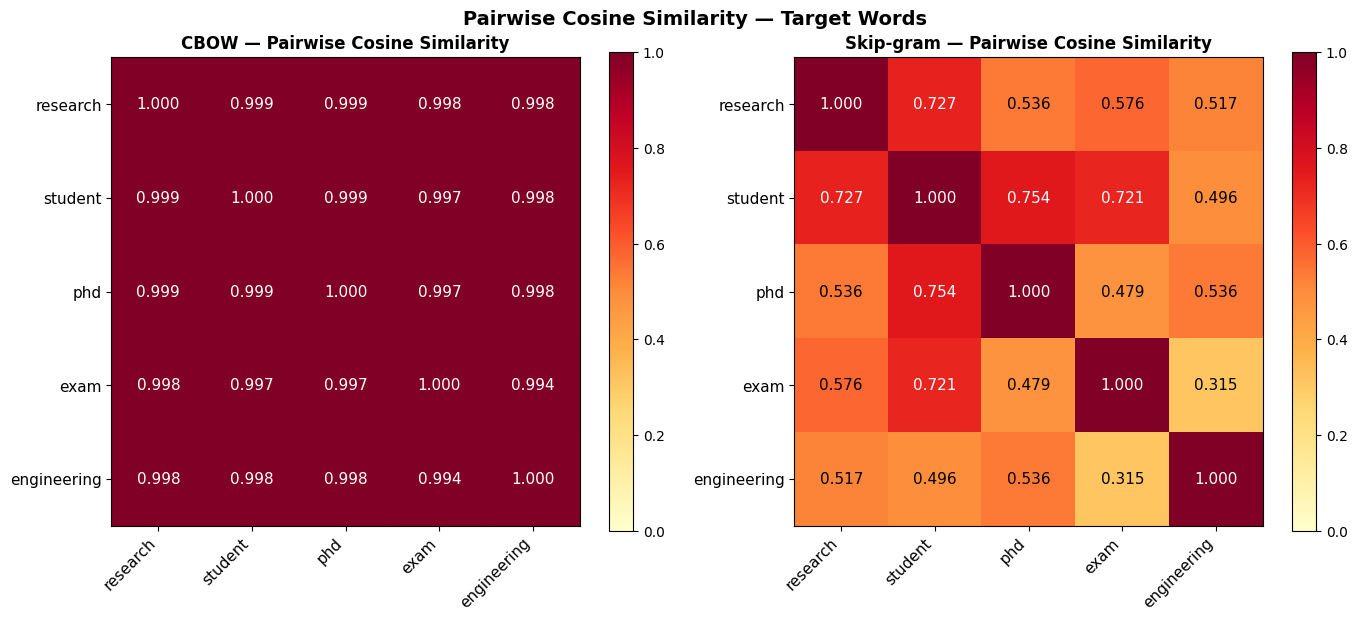

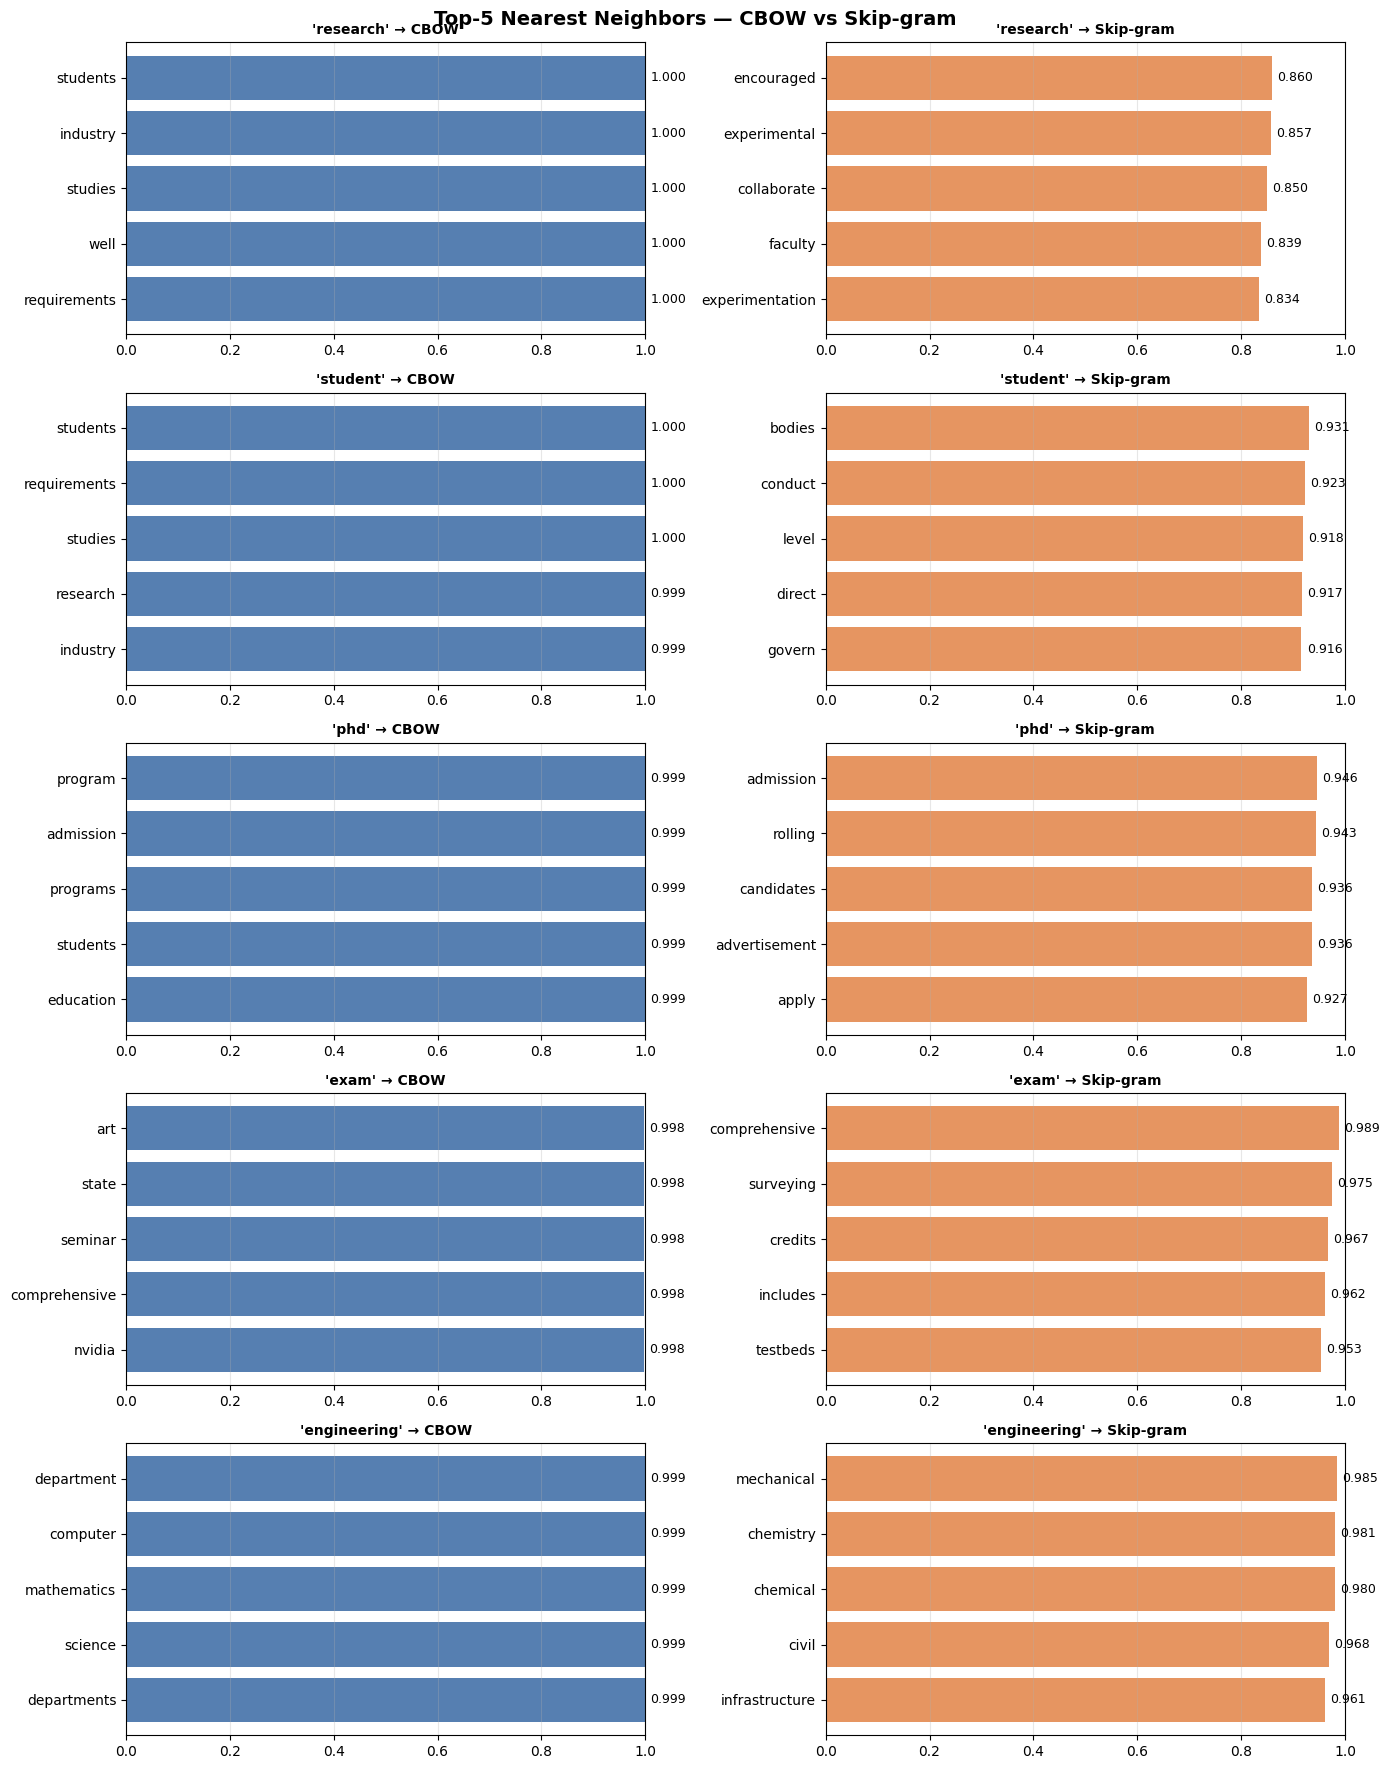

 Task 3 visualizations saved.


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (model, arch_name) in zip(axes,
        [(best_cbow_model,'CBOW'), (best_sg_model,'Skip-gram')]):

    words_in_v = [w for w in TARGET_WORDS if w in model.wv]
    n = len(words_in_v)
    sim_matrix = np.array([[model.wv.similarity(w1, w2)
                             for w2 in words_in_v]
                            for w1 in words_in_v])

    im = ax.imshow(sim_matrix, cmap='YlOrRd', vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(words_in_v, rotation=45, ha='right', fontsize=11)
    ax.set_yticklabels(words_in_v, fontsize=11)
    ax.set_title(f'{arch_name} — Pairwise Cosine Similarity', fontweight='bold')
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{sim_matrix[i,j]:.3f}', ha='center', va='center', fontsize=11,
                    color='black' if sim_matrix[i,j] < 0.7 else 'white')
    plt.colorbar(im, ax=ax)

plt.suptitle('Pairwise Cosine Similarity — Target Words', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_cosine_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Neighbor bar charts ───────────────────────────────────────────────
fig, axes = plt.subplots(len(TARGET_WORDS), 2, figsize=(14, 18))
fig.suptitle('Top-5 Nearest Neighbors — CBOW vs Skip-gram',
             fontsize=14, fontweight='bold')

for row_idx, word in enumerate(TARGET_WORDS):
    for col_idx, (key, arch_name, color) in enumerate([
            ('cbow','CBOW','#2c5f9e'), ('skipgram','Skip-gram','#e07b39')]):
        ax = axes[row_idx, col_idx]
        nbrs = nn_results[word][key]
        if nbrs:
            nbr_words  = [n[0] for n in nbrs]
            nbr_scores = [n[1] for n in nbrs]
            bars = ax.barh(range(len(nbr_words)), nbr_scores, color=color, alpha=0.8)
            ax.set_yticks(range(len(nbr_words)))
            ax.set_yticklabels(nbr_words, fontsize=10)
            ax.set_xlim(0, 1)
            ax.set_title(f"'{word}' → {arch_name}", fontsize=10, fontweight='bold')
            for bar, score in zip(bars, nbr_scores):
                ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                        f'{score:.3f}', va='center', fontsize=9)
            ax.grid(axis='x', alpha=0.3)
            ax.invert_yaxis()

plt.tight_layout()
plt.savefig('task3_neighbor_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Task 3 visualizations saved.')

---
##  TASK 4 — Visualization (PCA & t-SNE)
### 4.1 Define Word Clusters

In [29]:
CLUSTERS = {
    'Academic Programs' : ['btech','mtech','phd','doctoral','undergraduate','postgraduate',
                            'degree','program','programs','curriculum','courses','dual'],
    'Research'          : ['research','publication','thesis','dissertation','laboratory',
                            'projects','grants','funding','seminar','conferences'],
    'People & Roles'    : ['student','students','faculty','scholar','researchers',
                            'supervisor','alumni','candidates','admission'],
    'Departments'       : ['engineering','computer','electrical','mechanical','civil',
                            'chemistry','mathematics','physics','bioscience'],
    'AI & Technology'   : ['learning','intelligence','machine','computing','artificial',
                            'vision','network','systems','data','science'],
    'Collaboration'     : ['international','national','industry','collaboration',
                            'university','institute','exchange','joint','academic'],
}

CLUSTER_COLORS  = {
    'Academic Programs' : '#e74c3c',
    'Research'          : '#2980b9',
    'People & Roles'    : '#27ae60',
    'Departments'       : '#8e44ad',
    'AI & Technology'   : '#e67e22',
    'Collaboration'     : '#16a085',
}
CLUSTER_MARKERS = {
    'Academic Programs' : 'o',
    'Research'          : 's',
    'People & Roles'    : '^',
    'Departments'       : 'D',
    'AI & Technology'   : 'P',
    'Collaboration'     : '*',
}

def get_cluster_vectors(model, clusters):
    words, vectors, labels = [], [], []
    for cluster_name, word_list in clusters.items():
        for word in word_list:
            if word in model.wv:
                words.append(word)
                vectors.append(model.wv[word])
                labels.append(cluster_name)
    return words, np.array(vectors), labels

def scatter_plot(ax, coords, words, labels, title):
    seen = set()
    for i, (x, y) in enumerate(coords):
        cl = labels[i]
        ax.scatter(x, y, c=CLUSTER_COLORS[cl], marker=CLUSTER_MARKERS[cl],
                   s=90, alpha=0.85, edgecolors='white', linewidths=0.4,
                   label=cl if cl not in seen else '')
        seen.add(cl)
        ax.annotate(words[i], (x, y), textcoords='offset points',
                    xytext=(4, 4), fontsize=7, alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Component 1', fontsize=9)
    ax.set_ylabel('Component 2', fontsize=9)
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

LEGEND_HANDLES = [mpatches.Patch(color=CLUSTER_COLORS[c], label=c) for c in CLUSTERS]
print(' Cluster definitions ready.')

 Cluster definitions ready.


### 4.2 PCA Projection

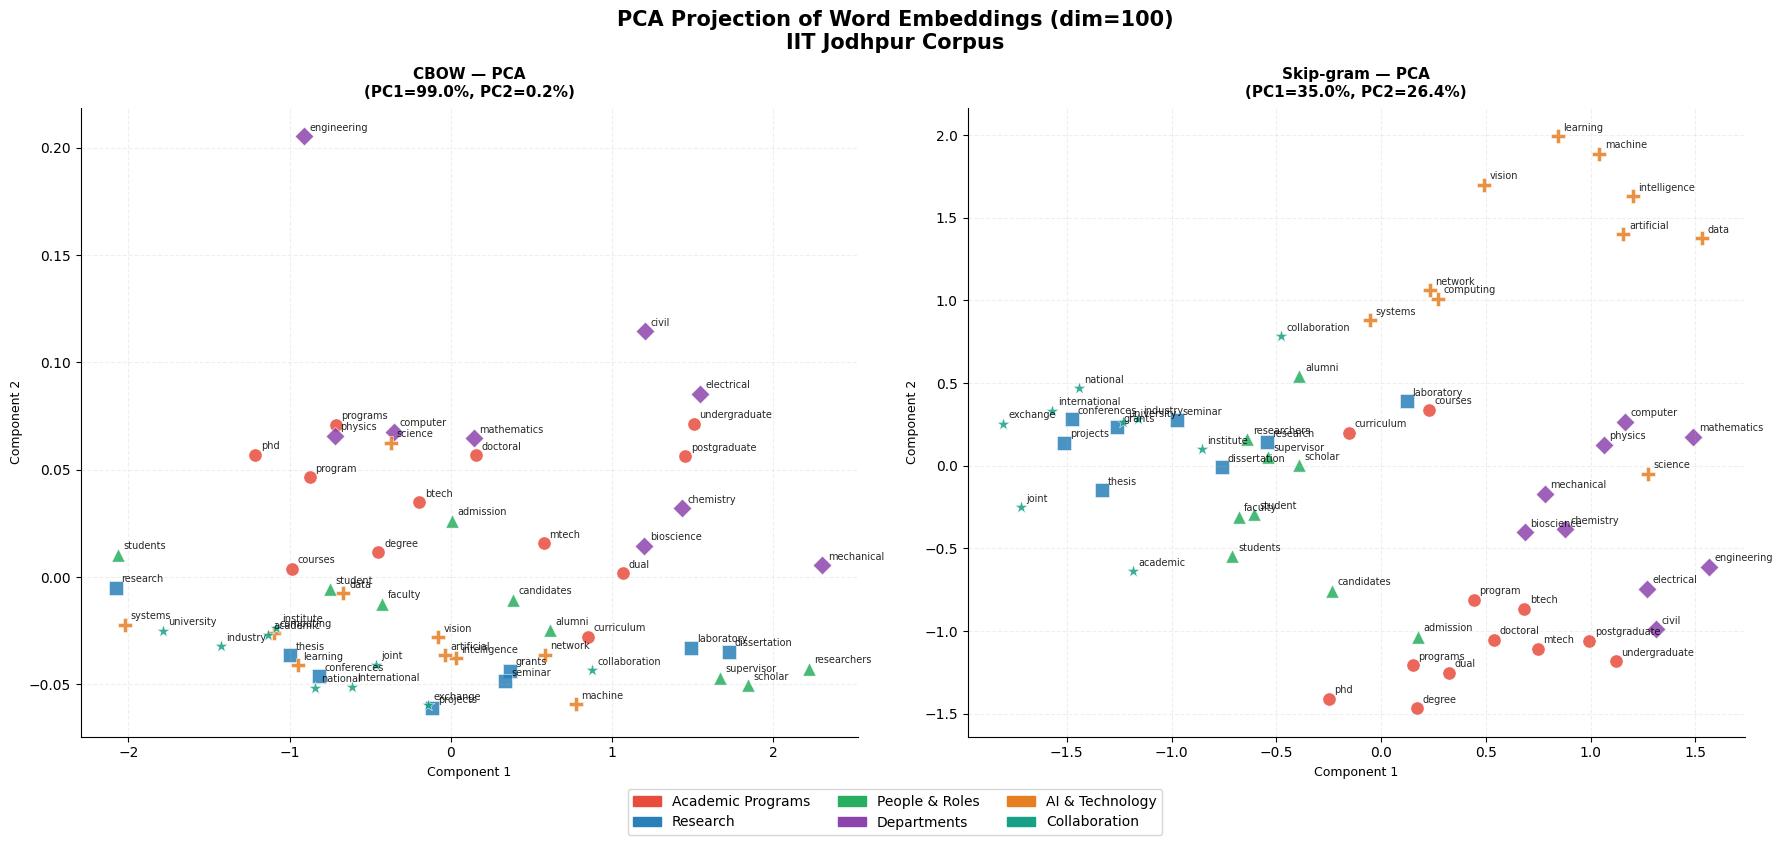

✅ PCA plot saved.


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('PCA Projection of Word Embeddings (dim=100)\nIIT Jodhpur Corpus',
             fontsize=15, fontweight='bold')

for ax, (model, arch_name) in zip(axes,
        [(best_cbow_model,'CBOW'), (best_sg_model,'Skip-gram')]):
    words, vectors, labels = get_cluster_vectors(model, CLUSTERS)
    pca    = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(vectors)
    var    = pca.explained_variance_ratio_
    scatter_plot(ax, coords, words, labels,
                 f'{arch_name} — PCA\n(PC1={var[0]:.1%}, PC2={var[1]:.1%})')

fig.legend(handles=LEGEND_HANDLES, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.06), frameon=True)
plt.tight_layout()
plt.savefig('task4_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ PCA plot saved.')

### 4.3 t-SNE Projection

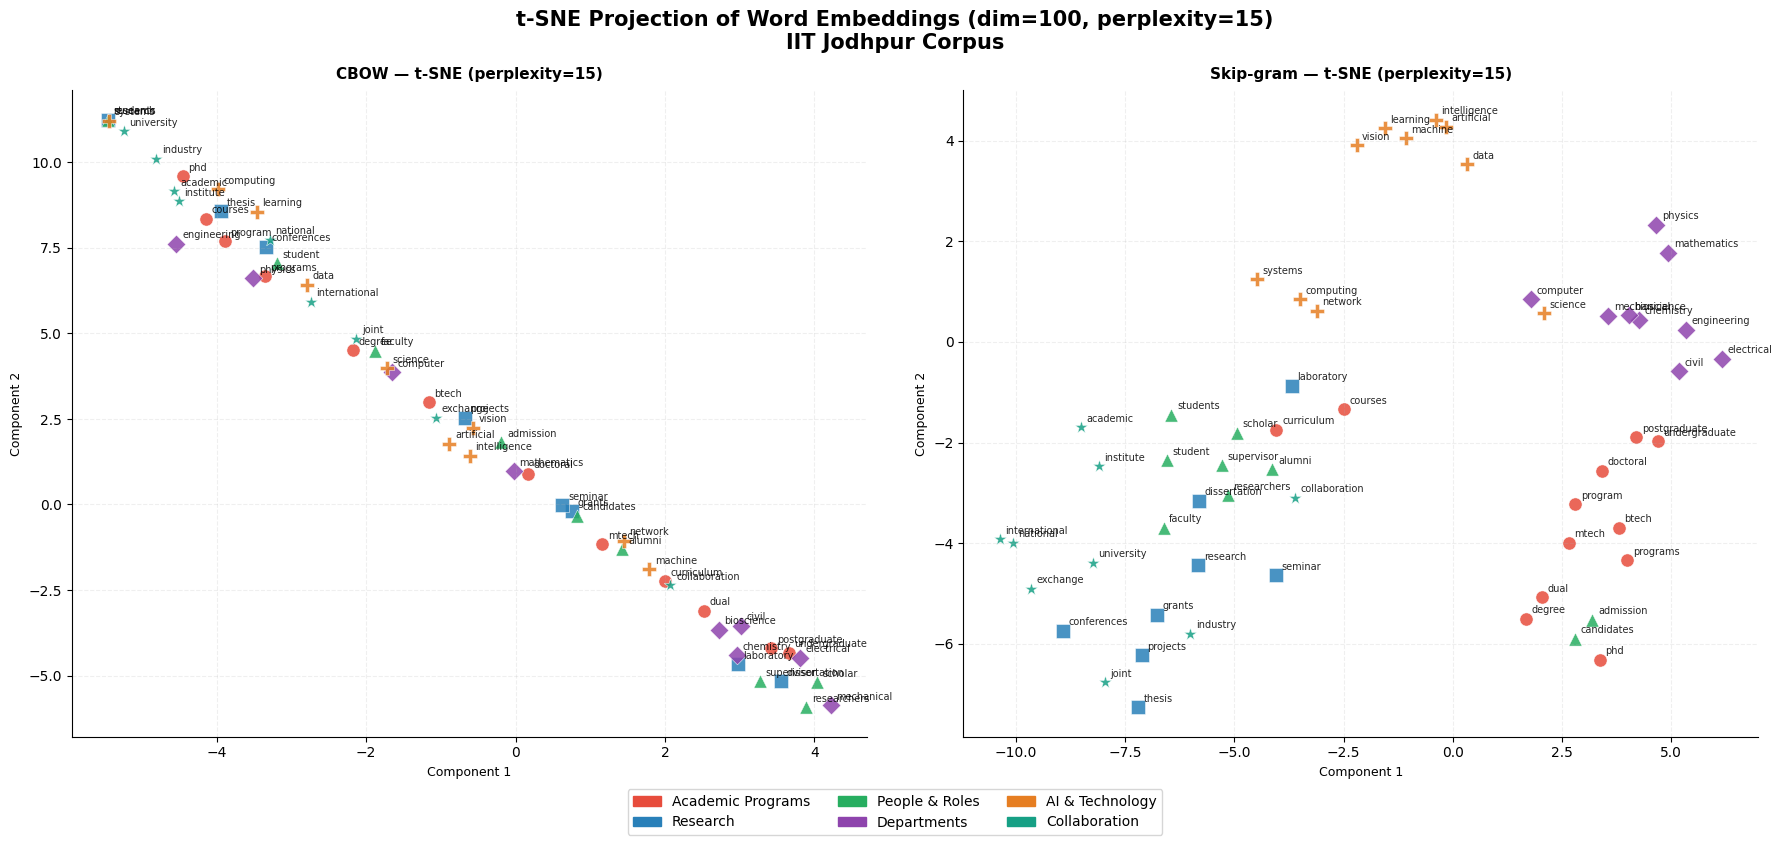

 t-SNE plot saved.


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('t-SNE Projection of Word Embeddings (dim=100, perplexity=15)\nIIT Jodhpur Corpus',
             fontsize=15, fontweight='bold')

for ax, (model, arch_name) in zip(axes,
        [(best_cbow_model,'CBOW'), (best_sg_model,'Skip-gram')]):
    words, vectors, labels = get_cluster_vectors(model, CLUSTERS)
    perp   = min(15, len(words) - 1)
    tsne   = TSNE(n_components=2, perplexity=perp, max_iter=1500,
                  random_state=42, learning_rate='auto', init='pca')
    coords = tsne.fit_transform(vectors)
    scatter_plot(ax, coords, words, labels,
                 f'{arch_name} — t-SNE (perplexity={perp})')

fig.legend(handles=LEGEND_HANDLES, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.06), frameon=True)
plt.tight_layout()
plt.savefig('task4_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print(' t-SNE plot saved.')

### 4.4 Combined 2×2 Grid (PCA + t-SNE × CBOW + Skip-gram)

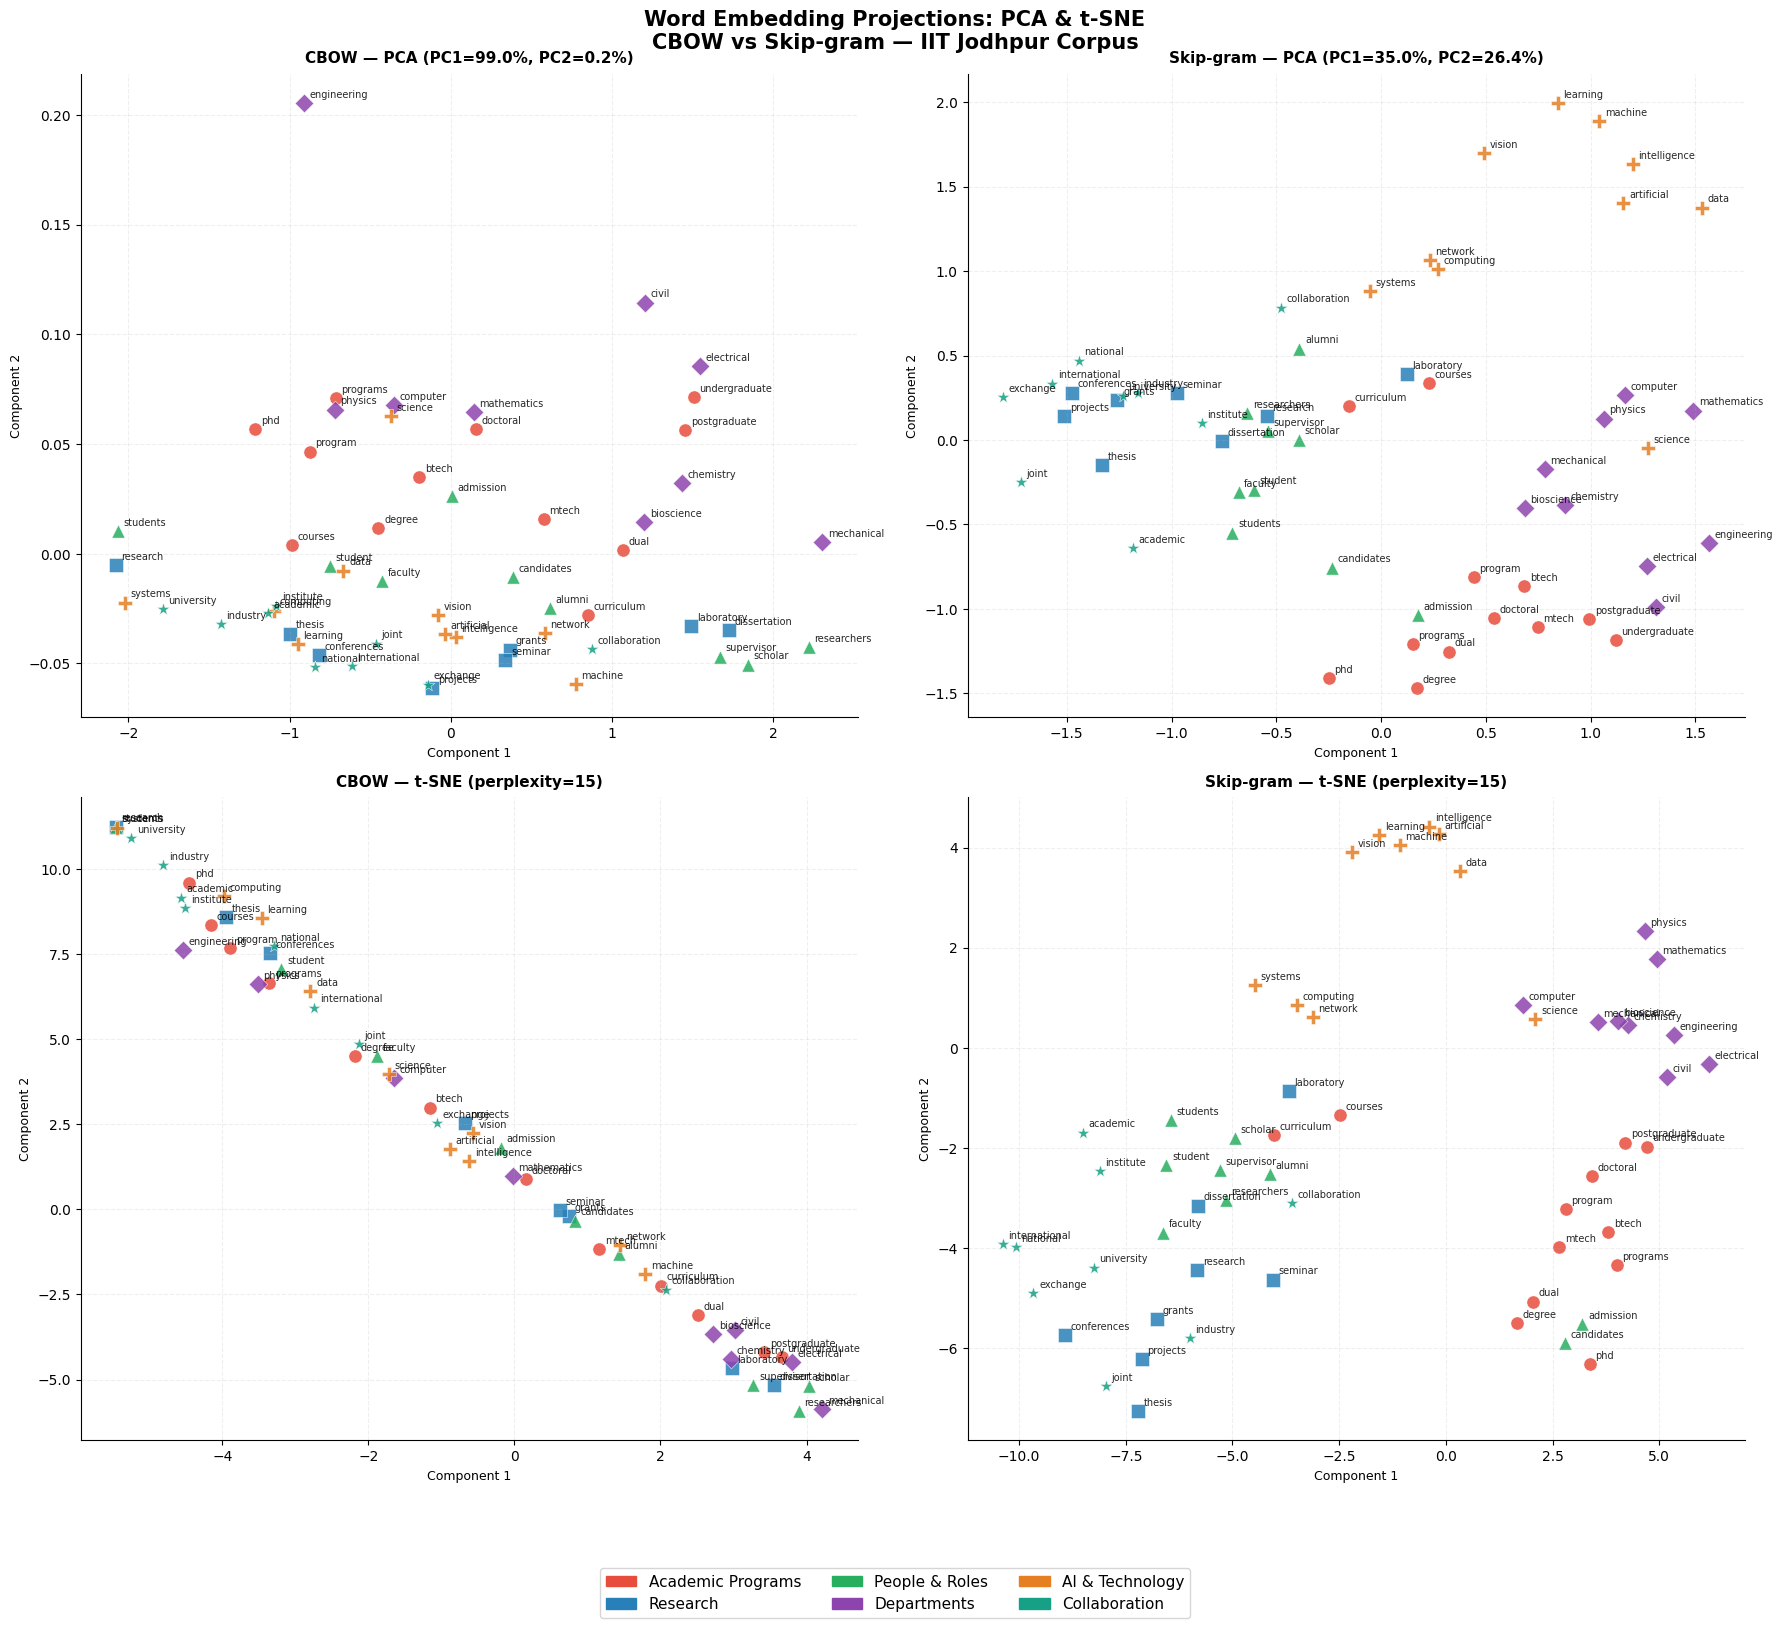

 Combined 2×2 plot saved.


In [32]:
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
fig.suptitle('Word Embedding Projections: PCA & t-SNE\nCBOW vs Skip-gram — IIT Jodhpur Corpus',
             fontsize=15, fontweight='bold')

for col_idx, (model, arch_name) in enumerate(
        [(best_cbow_model,'CBOW'), (best_sg_model,'Skip-gram')]):

    words, vectors, labels = get_cluster_vectors(model, CLUSTERS)

    # PCA — row 0
    pca    = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(vectors)
    var    = pca.explained_variance_ratio_
    scatter_plot(axes[0, col_idx], coords, words, labels,
                 f'{arch_name} — PCA (PC1={var[0]:.1%}, PC2={var[1]:.1%})')

    # t-SNE — row 1
    perp   = min(15, len(words) - 1)
    tsne   = TSNE(n_components=2, perplexity=perp, max_iter=1500,
                  random_state=42, learning_rate='auto', init='pca')
    coords = tsne.fit_transform(vectors)
    scatter_plot(axes[1, col_idx], coords, words, labels,
                 f'{arch_name} — t-SNE (perplexity={perp})')

fig.legend(handles=LEGEND_HANDLES, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, -0.03), frameon=True)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('task4_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Combined 2×2 plot saved.')

### 4.5 'research' Word Neighborhood (PCA zoom)

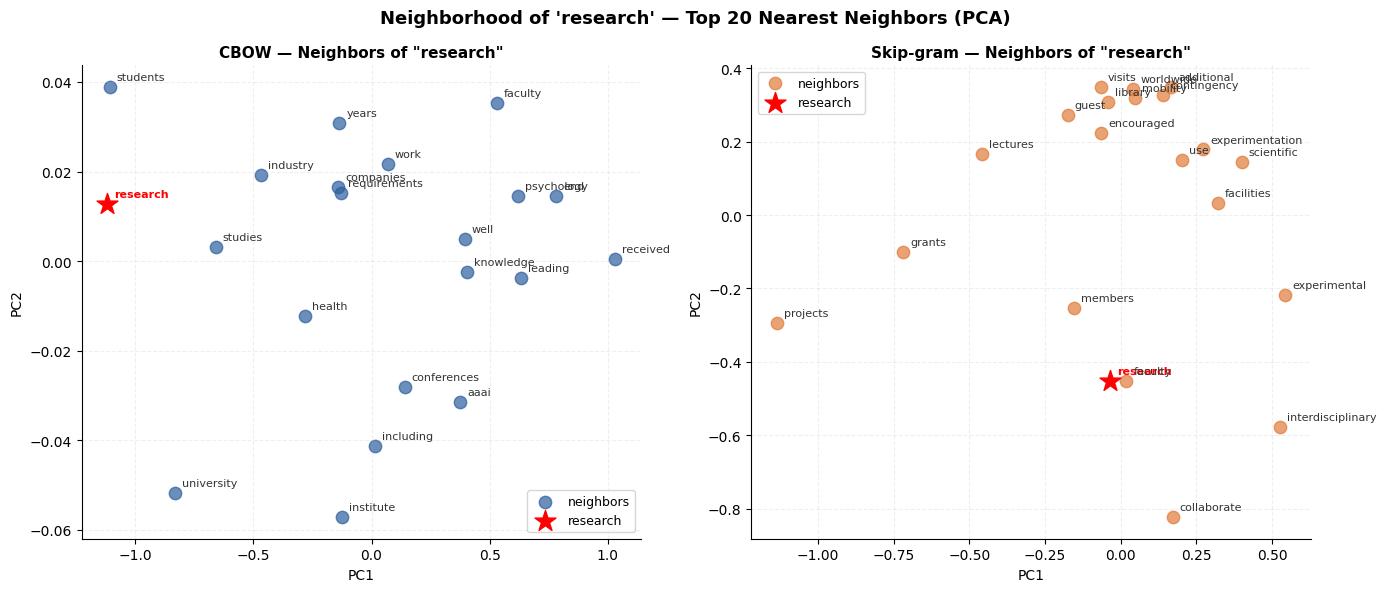

 Research neighborhood plot saved.


In [33]:
FOCUS_WORD  = 'research'
N_NEIGHBORS = 20

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Neighborhood of '{FOCUS_WORD}' — Top {N_NEIGHBORS} Nearest Neighbors (PCA)",
             fontsize=13, fontweight='bold')

for ax, (model, arch_name, color) in zip(axes, [
        (best_cbow_model, 'CBOW',      '#2c5f9e'),
        (best_sg_model,   'Skip-gram', '#e07b39')]):

    neighbors  = model.wv.most_similar(FOCUS_WORD, topn=N_NEIGHBORS)
    nbr_words  = [FOCUS_WORD] + [w for w, _ in neighbors]
    nbr_vecs   = np.array([model.wv[w] for w in nbr_words])
    pca_local  = PCA(n_components=2, random_state=42)
    coords     = pca_local.fit_transform(nbr_vecs)

    ax.scatter(coords[1:, 0], coords[1:, 1], c=color, s=80, alpha=0.7, label='neighbors')
    ax.scatter(coords[0, 0],  coords[0, 1],  c='red',  s=250, marker='*',
               zorder=5, label=FOCUS_WORD)
    for i, word in enumerate(nbr_words):
        ax.annotate(word, coords[i], textcoords='offset points', xytext=(5, 5),
                    fontsize=8,
                    color='red'     if i == 0 else '#333333',
                    fontweight='bold' if i == 0 else 'normal')

    ax.set_title(f'{arch_name} — Neighbors of "{FOCUS_WORD}"',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('task4_research_neighborhood.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Research neighborhood plot saved.')

---
##  Summary — All Files Generated

In [34]:
import os

output_files = [
    ('best_cbow.model',                   'Task 2 — Best CBOW model (dim=100, win=5, neg=5)'),
    ('best_skipgram.model',               'Task 2 — Best Skip-gram model (dim=100, win=5, neg=5)'),
    ('task1_wordcloud_and_frequency.png', 'Task 1 — Word cloud + frequency bar chart'),
    ('task2_training_heatmap.png',        'Task 2 — Training time heatmap (CBOW vs SG)'),
    ('task3_cosine_heatmap.png',          'Task 3 — Pairwise cosine similarity heatmap'),
    ('task3_neighbor_bars.png',           'Task 3 — Top-5 neighbor bar charts'),
    ('task4_pca.png',                     'Task 4 — PCA projection (CBOW vs SG)'),
    ('task4_tsne.png',                    'Task 4 — t-SNE projection (CBOW vs SG)'),
    ('task4_combined.png',                'Task 4 — Combined 2x2 PCA + t-SNE grid'),
    ('task4_research_neighborhood.png',   'Task 4 — research word neighborhood'),
]

print('=' * 65)
print('  OUTPUT FILES GENERATED')
print('=' * 65)
for fname, desc in output_files:
    exists = '' if os.path.exists(fname) else ' MISSING'
    size   = f"{os.path.getsize(fname)/1024:.1f} KB" if os.path.exists(fname) else ''
    print(f'  {exists}  {fname:<42} {size:>10}  — {desc}')

print('\n' + '=' * 65)
print('  CORPUS STATISTICS RECAP')
print('=' * 65)
print(f'  Documents          : {total_docs}')
print(f'  Tokens (raw)       : {total_tokens_raw}')
print(f'  Tokens (filtered)  : {total_tokens_filtered}')
print(f'  Vocabulary size    : {vocab_size}')
print(f'  W2V sentences      : {num_sentences}')
print(f'  Models trained     : {len(training_results)} (27 CBOW + 27 Skip-gram)')
print(f'  Best config        : dim=100, win=5, neg=5, epochs=50')
print('=' * 65)
print('\n All 4 tasks complete!')

  OUTPUT FILES GENERATED
    best_cbow.model                              782.1 KB  — Task 2 — Best CBOW model (dim=100, win=5, neg=5)
    best_skipgram.model                          782.1 KB  — Task 2 — Best Skip-gram model (dim=100, win=5, neg=5)
    task1_wordcloud_and_frequency.png            641.2 KB  — Task 1 — Word cloud + frequency bar chart
    task2_training_heatmap.png                    77.2 KB  — Task 2 — Training time heatmap (CBOW vs SG)
    task3_cosine_heatmap.png                     122.1 KB  — Task 3 — Pairwise cosine similarity heatmap
    task3_neighbor_bars.png                      253.0 KB  — Task 3 — Top-5 neighbor bar charts
    task4_pca.png                                285.9 KB  — Task 4 — PCA projection (CBOW vs SG)
    task4_tsne.png                               285.8 KB  — Task 4 — t-SNE projection (CBOW vs SG)
    task4_combined.png                           537.3 KB  — Task 4 — Combined 2x2 PCA + t-SNE grid
    task4_research_neighborhood.png        